# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/).

**Se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.


## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/)). Para la entrega 2 hay nuevas dependencias, por lo que es importante correr la siguiente celda.

In [17]:
# Instalación de librerías necesarias
!pip install jupyter pandas seaborn pillow networkx nltk scikit-learn


  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached notebook-7.4.3-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.16.6-py3-none-any.whl.metadata (8.5 kB)
  Using cached ipywidgets-8.1.7-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.4.3-py3-none-any.whl.metadata (16 kB)
  Using cached click-8.2.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached regex-2024.11.6-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached widgetsnbextension-4.0.14-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl.metadata (20 kB)
  Using cached async_lru-2.0.5-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata 


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import re
import os

from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
import nltk
import matplotlib.patches as mpatches


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

## Lectura de Datos

In [19]:
# DataFrame con todos los discursos:
df_speeches = pd.read_csv('./data/us_2020_election_speeches.csv')
df_speeches

,speaker,title,text,date,location,type
0,David Perdue,Georgia Sen. David Perdue Speech Transcript at...,David Perdue: (00:01)\r\nHow great is it to be...,"Oct 16, 2020","Macon, Georgia",Campaign Speech
1,Joe Biden,"Joe Biden Southfield, MI Speech on Health Care...","Joe Biden: (00:00)\r\nHello, Michigan. Hi, how...","Oct 16, 2020","Southfield ,Michigan",Campaign Speech
2,Donald Trump,Donald Trump Speech Transcript ‘Protecting Ame...,President Trump: (00:30)\r\nThank you. What a ...,"Oct 16, 2020","Fort Myers, Florida",Campaign Speech
3,Joe Biden,Joe Biden ABC Town Hall Transcript October 15,"George Stephanopoulos: (00:41)\r\nHey, and wel...","Oct 15, 2020",ABC,Town Hall
4,Donald Trump,Donald Trump NBC Town Hall Transcript October 15,Savannah Guthrie: (03:50)\r\nIt’s nothing but ...,"Oct 15, 2020",NBC,Town Hall
...,...,...,...,...,...,...
264,Bernie Sanders,Bernie Sanders Speech Transcript: Sanders Spea...,Bernie Sanders: (00:00)\r\nJust want to take t...,"Feb 6, 2020",Iowa,Campaign Speech
265,Democratic Candidates,Transcript: Speeches at the Iowa Caucuses – Be...,Bernie Sanders: (00:08)\r\nThank you. Thank yo...,"Feb 4, 2020",Iowa,Campaign Speech
266,Donald Trump,Donal Trump Iowa Rally Transcript: Trump Holds...,Donald Trump: (00:24)\r\nI worked so hard for ...,"Jan 30, 2020","Des Moines, Iowa",Campaign Speech
267,Donald Trump,Donald Trump New Jersey Rally Speech Transcrip...,Donald Trump: (01:22)\r\nThank you. Thank you....,"Jan 28, 2020","Wildwood, New Jersey",Campaign Speech


In [20]:
# Realizar la limpieza de los datos que crea pertinente. Se espera que usen la función clean_text() de la entrega anterior.
# df_speeches_clean = ...

# Función de limpieza reutilizada de la Tarea 1
def clean_text(df, column_name):
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)
    result = result.str.lower()
    punctuation = ["[", "\n", ",", ":", "?", ".", "!", ";", "(", ")", "\"", "'"]
    for punc in punctuation:
        result = result.str.replace(punc, " ", regex=False)
    result = result.str.replace(r'\s+', ' ', regex=True)
    result = result.str.strip()
    return result

# Aplicar la limpieza a la columna 'text'
df_speeches['CleanText'] = clean_text(df_speeches, 'text')

# Crear copia para trabajar con datos limpios
df_speeches_clean = df_speeches.copy()

# Vista previa de los resultados
df_speeches_clean[['speaker', 'text', 'CleanText']].head()


,speaker,text,CleanText
0,David Perdue,David Perdue: (00:01)\r\nHow great is it to be...,how great is it to be back in macon georgia wi...
1,Joe Biden,"Joe Biden: (00:00)\r\nHello, Michigan. Hi, how...",hello michigan hi how are you what’s your name...
2,Donald Trump,President Trump: (00:30)\r\nThank you. What a ...,thank you what a nice group thank you very muc...
3,Joe Biden,"George Stephanopoulos: (00:41)\r\nHey, and wel...",hey and welcome to our town hall with joe bide...
4,Donald Trump,Savannah Guthrie: (03:50)\r\nIt’s nothing but ...,it’s nothing but noise what okay all right lad...


In [21]:
# Filtramos los 3 candidatos con más discursos.

# top_5_candidates = df_speeches_clean["speaker"].value_counts().head(5).index
# print(f"Top 3 candidatos: {top_3_candidates}")
# print("---------------")

# df_speeches_top_3 = df_speeches_clean[
#     df_speeches_clean["speaker"].isin(top_3_candidates)
# ]
# df_speeches_top_3


# Obtener los 3 candidatos con mayor cantidad de discursos
top_3_candidates = df_speeches_clean["speaker"].value_counts().head(3).index.tolist()
print(f"Top 3 candidatos: {top_3_candidates}")
print("---------------")

# Filtrar el DataFrame con solo esos candidatos
df_speeches_top_3 = df_speeches_clean[df_speeches_clean["speaker"].isin(top_3_candidates)]

# Vista previa
df_speeches_top_3[["speaker", "CleanText"]].head()


Top 3 candidatos: ['Joe Biden', 'Donald Trump', 'Mike Pence']
---------------


,speaker,CleanText
1,Joe Biden,hello michigan hi how are you what’s your name...
2,Donald Trump,thank you what a nice group thank you very muc...
3,Joe Biden,hey and welcome to our town hall with joe bide...
4,Donald Trump,it’s nothing but noise what okay all right lad...
5,Donald Trump,thank you very much thank you let’s see it’s 1...


## Parte 1: Dataset y representación numérica de texto

In [22]:
# 1: Separar 30% del conjunto para test. Al resto lo llamamos "dev" (desarrollo).

# X_dev, X_test, y_dev, y_test = ...
# print(f"Tamaños de los conjuntos: {X_dev.shape}, {X_test.shape}")

!pip install scikit-learn

from sklearn.model_selection import train_test_split

# Definir variables predictoras (texto limpio) y etiquetas (candidato)
X = df_speeches_top_3["CleanText"]
y = df_speeches_top_3["speaker"]

# División 70% dev, 30% test
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Mostrar tamaños resultantes
print(f"Tamaño conjunto de desarrollo (dev): {X_dev.shape[0]}")
print(f"Tamaño conjunto de prueba (test): {X_test.shape[0]}")


Tamaño conjunto de desarrollo (dev): 100
Tamaño conjunto de prueba (test): 43



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


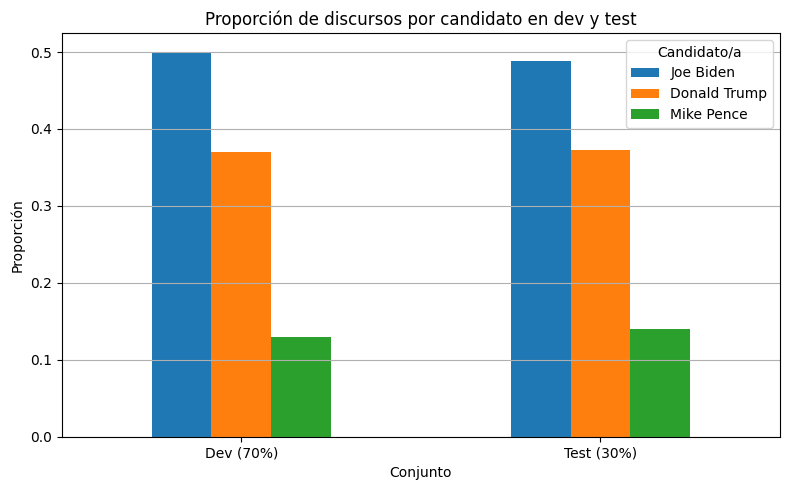

In [23]:
# 2: Visualización de la proporción de cada candidato por conjunto
import matplotlib.pyplot as plt

# Contar instancias por clase en cada conjunto
dev_counts = y_dev.value_counts(normalize=True)
test_counts = y_test.value_counts(normalize=True)

# Crear DataFrame combinado para graficar
proportion_df = pd.DataFrame({
    "Dev (70%)": dev_counts,
    "Test (30%)": test_counts
}).T

# Graficar
proportion_df.plot(kind="bar", figsize=(8, 5), rot=0)
plt.title("Proporción de discursos por candidato en dev y test")
plt.xlabel("Conjunto")
plt.ylabel("Proporción")
plt.legend(title="Candidato/a")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [24]:
# 3: Transforme el texto del conjunto de entrenamiento a la representación numérica (features) de conteo de palabras o bag of words.

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Inicializar vectorizador BoW
vectorizer = CountVectorizer()

# Ajustar al conjunto de desarrollo y transformar
X_dev_bow = vectorizer.fit_transform(X_dev)
X_test_bow = vectorizer.transform(X_test)

# Aplicar TF-IDF sobre la matriz BoW
tfidf = TfidfTransformer()
X_dev_tfidf = tfidf.fit_transform(X_dev_bow)
X_test_tfidf = tfidf.transform(X_test_bow)

# Mostrar dimensiones de las matrices
print(f"BoW shape (dev): {X_dev_bow.shape}")
print(f"TF-IDF shape (dev): {X_dev_tfidf.shape}")



BoW shape (dev): (100, 13669)
TF-IDF shape (dev): (100, 13669)


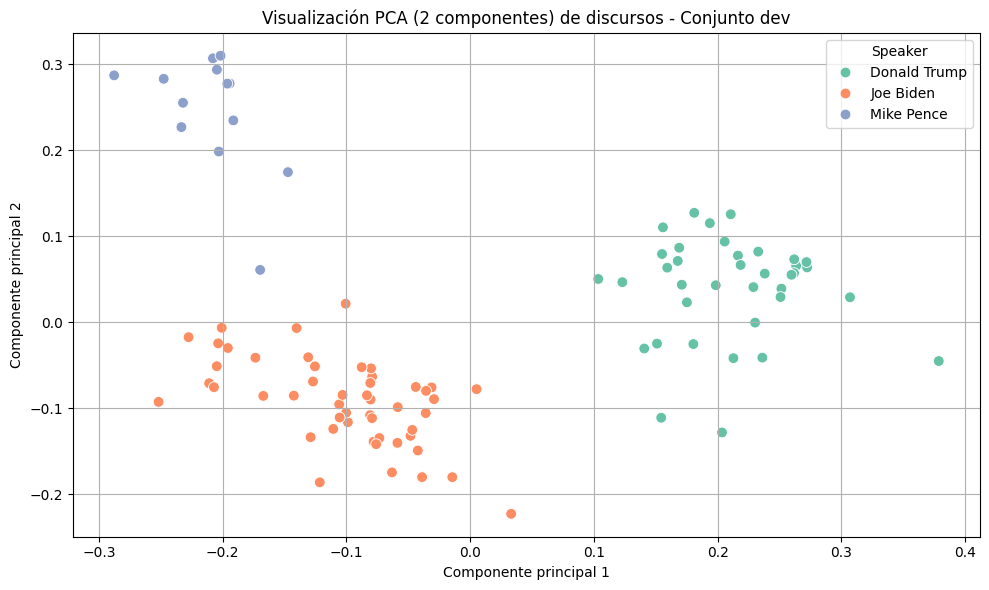

In [25]:
# 4: Obtenga la representación numérica Term Frequency - Inverse Document Frequency.


from sklearn.decomposition import PCA

# Reducir a 2 dimensiones usando PCA
pca = PCA(n_components=2)
X_dev_pca = pca.fit_transform(X_dev_tfidf.toarray())

# Crear DataFrame para graficar
pca_df = pd.DataFrame({
    'PCA1': X_dev_pca[:, 0],
    'PCA2': X_dev_pca[:, 1],
    'Speaker': y_dev.values
})

# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Speaker', palette='Set2', s=60)
plt.title('Visualización PCA (2 componentes) de discursos - Conjunto dev')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 5 :Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de tf-idf.


# Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (e.g: hasta 10 componentes).




## Parte 2: Entrenamiento y Evaluación de Modelos


In [ ]:
# 1: Entrene el modelo Multinomial Naive Bayes, luego utilícelo para predecir sobre el conjunto de test, y reporte el valor de accuracy y la matriz de confusión. Reporte el valor de precision y recall para cada candidato. 
# Calcular matriz de confusión Sugerencia: utilice el método from_predictions de ConfusionMatrixDisplay para realizar la matriz.

In [ ]:
# 2: Implemente una búsqueda de hiperparámetros usando GridSearchCV.

# Genere una visualización que permita comparar las métricas (e.g: accuracy) de los distintos modelos entrenados, viendo el valor promedio y variabilidad de las mismas en todos los splits (e.g: en un gráfico de violín).


In [ ]:
# 3: Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación). Reporte el valor final de las métricas y la matriz de confusión.


In [ ]:
# 4: Evalúe con validación cruzada al menos un modelo más (dentro de scikit-learn) aparte de Multinomial Naive Bayes para clasificar el texto utilizando las mismas features de texto.


In [1]:
# 5: Evalúe el problema cambiando al menos un candidato. En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.

In [ ]:
# OPCIONAL: Repetir la clasificación con los tres candidatos con más discursos, pero esta vez clasificando a nivel de párrafos y no de discursos enteros.
